**Transition vs Transversion ratio**

Ts/Tv SUMMARY
  paeruginosa                    Ts= 10657  Tv=  6600  Ts/Tv=1.615
  styphimurium                   Ts=  2181  Tv=  1471  Ts/Tv=1.483
  bpertussis                     Ts=  1586  Tv=   662  Ts/Tv=2.396
  sagalactiae                    Ts=  7497  Tv=  3098  Ts/Tv=2.420
  nmeningitidis                  Ts=  3835  Tv=   778  Ts/Tv=4.929
  cjejuni                        Ts=  5444  Tv=   705  Ts/Tv=7.722
  ecoli                          Ts= 23604  Tv=  9332  Ts/Tv=2.529
  spneumoniae                    Ts=  4471  Tv=  1700  Ts/Tv=2.630
  kpneumoniae                    Ts= 42659  Tv= 21847  Ts/Tv=1.953
  hinfluenzae                    Ts=  3335  Tv=  1124  Ts/Tv=2.967
  sepidermidis                   Ts=  9957  Tv=  5710  Ts/Tv=1.744
  lmonocytogenesA                Ts=  7972  Tv=  3690  Ts/Tv=2.160
  saureus                        Ts= 14846  Tv=  6270  Ts/Tv=2.368
  mtuberculosis                  Ts= 20472  Tv= 10737  Ts/Tv=1.907

Overall chi-squared test across all species
  C

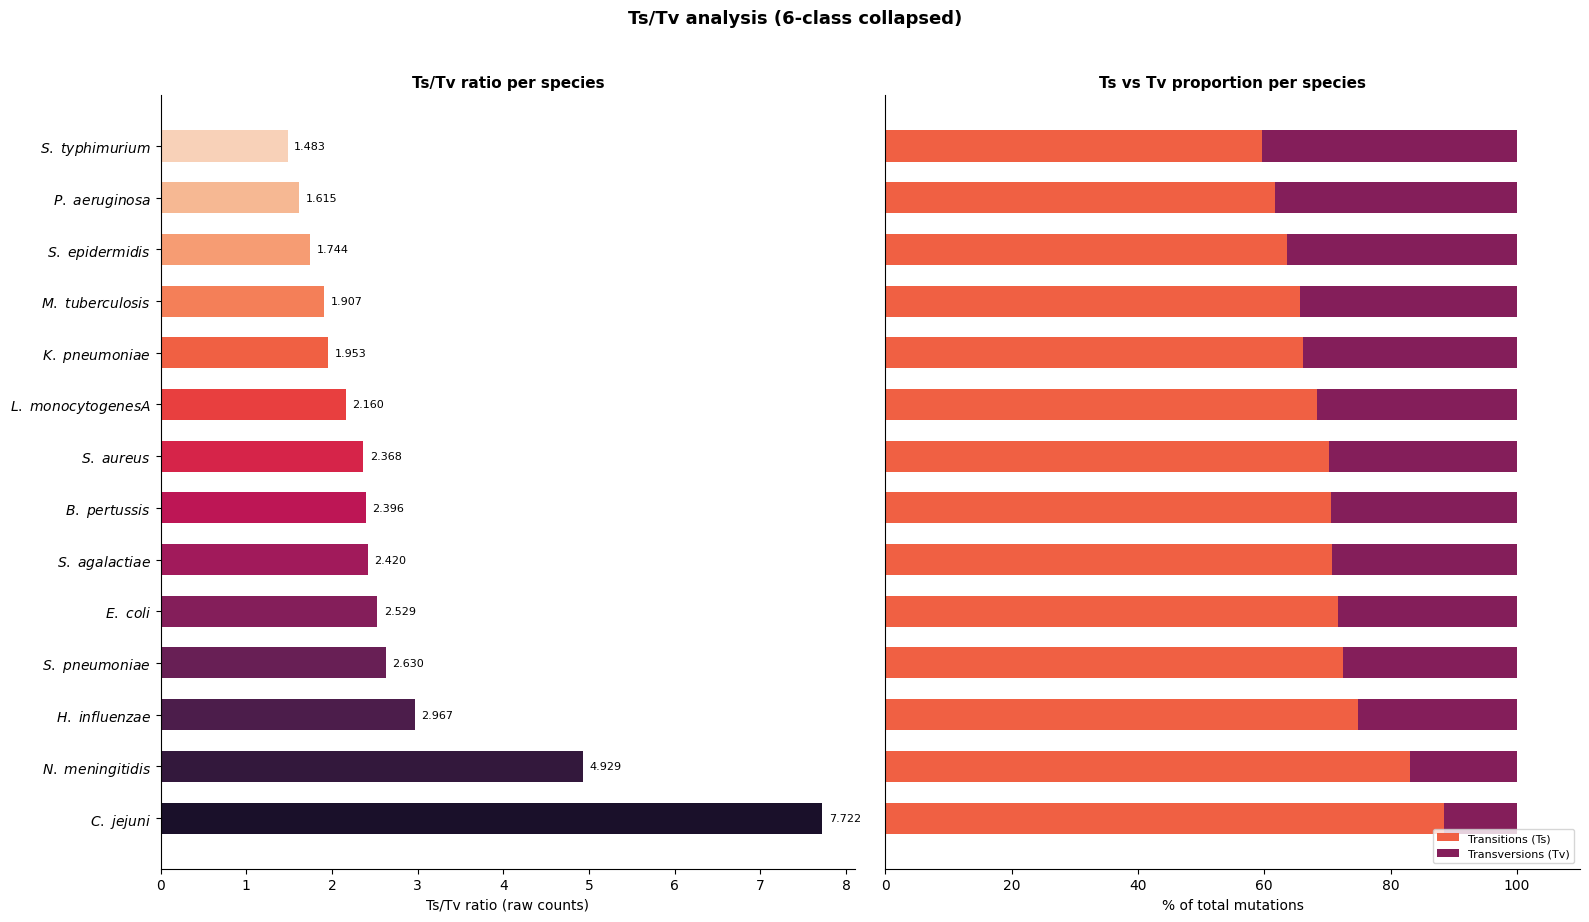

Saved tstv_ratio.png


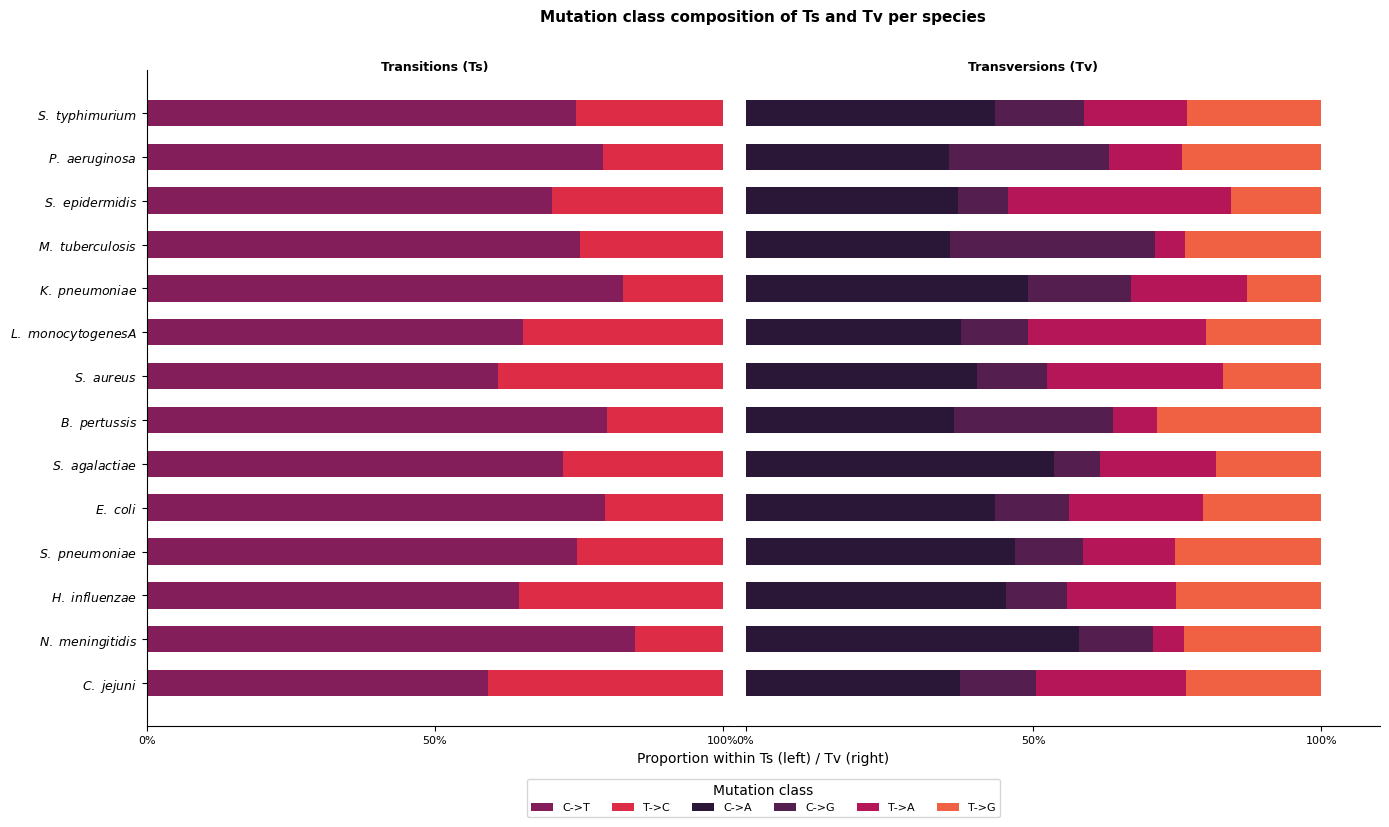

Saved tstv_composition.png


In [23]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings("ignore")

# paths
file = os.path.expanduser(
    "~/shared-team/2025-masters-project/people/eleanor/original_and_processed_files/processed_c/mutation_summary_final_c.csv"
)
output_folder = os.path.expanduser(
    "~/shared-team/2025-masters-project/people/eleanor/original_and_processed_files/processed_c/charts/ts_tv"
)
os.makedirs(output_folder, exist_ok=True)

DPI = 300

# define ts and tv and classes
TRANSITIONS   = {"C->T", "T->C"}
TRANSVERSIONS = {"C->A", "C->G", "T->A", "T->G"}
MUT_CLASSES   = ["C->A", "C->G", "C->T", "T->A", "T->C", "T->G"]

# Rocket mutation class colours — consistent with all other graphs
ROCKET_6    = sns.color_palette("rocket", 8)
MUT_COLOURS = {
    "C->A": ROCKET_6[0],
    "C->G": ROCKET_6[1],
    "C->T": ROCKET_6[2],
    "T->A": ROCKET_6[3],
    "T->C": ROCKET_6[4],
    "T->G": ROCKET_6[5],
}

# Ts/Tv colours
ts_color = sns.color_palette("rocket", 2)[1]
tv_color = sns.color_palette("rocket", 2)[0]


def format_species_name(name):
    genus_initial = name[0].upper()
    rest          = name[1:]
    return f"$\\it{{{genus_initial}.\\ {rest}}}$"

############
# loop through species in file and find classes numbers, calculate ratios, print what ive found
df           = pd.read_csv(file)
species_list = df["species"].unique().tolist()

print("Ts/Tv SUMMARY")
summary_rows = []

for species in species_list:
    sp_df  = df[df["species"] == species]
    ts_muts = sp_df[sp_df["mutation_class"].isin(TRANSITIONS)]["no_mutations"].sum()
    tv_muts = sp_df[sp_df["mutation_class"].isin(TRANSVERSIONS)]["no_mutations"].sum()
    total   = ts_muts + tv_muts
    ratio   = ts_muts / tv_muts if tv_muts > 0 else np.nan

    summary_rows.append({
        "species":     species,
        "ts_count":    int(ts_muts),
        "tv_count":    int(tv_muts),
        "total":       int(total),
        "ts_pct":      ts_muts / total * 100 if total > 0 else 0,
        "tv_pct":      tv_muts / total * 100 if total > 0 else 0,
        "ts_tv_ratio": ratio,
    })
    print(f"  {species:<30} Ts={int(ts_muts):>6}  Tv={int(tv_muts):>6}  Ts/Tv={ratio:.3f}")

summary_df = pd.DataFrame(summary_rows).sort_values("ts_tv_ratio", ascending=False)
summary_df.to_csv(os.path.join(output_folder, "tstv_ratio.csv"), index=False)

# Per-class breakdown for composition plot
per_class_df = (
    df[df["mutation_class"].isin(TRANSITIONS | TRANSVERSIONS)]
    .assign(type=lambda d: np.where(d["mutation_class"].isin(TRANSITIONS), "Ts", "Tv"))
    .groupby(["species", "mutation_class", "type"], as_index=False)["no_mutations"]
    .sum()
)
per_class_df.to_csv(os.path.join(output_folder, "tstv_per_class.csv"), index=False)

#################
#stats

# goodness of fit chi squared over all species
print("\nOverall chi-squared test across all species")

contingency = summary_df[["species", "ts_count", "tv_count"]].set_index("species")
chi2_stat, p_chi2, dof, expected = chi2_contingency(contingency.values)

sig_overall = significance_stars(p_chi2)
print(f"  Chi-squared statistic: {chi2_stat:.3f}")
print(f"  Degrees of freedom:    {dof}")
print(f"  p-value:               {p_chi2:.6f}  {sig_overall}")


# pairwise chi swquared
print("\nperforming Pairwise chi-squared tests ")

species_names = summary_df["species"].tolist()
pair_rows     = []

#generates pairs without repeating and runs pairwise on them
for i, sp_a in enumerate(species_names):
    for sp_b in species_names[i+1:]:
        row_a = summary_df[summary_df["species"] == sp_a].iloc[0]
        row_b = summary_df[summary_df["species"] == sp_b].iloc[0]
        table = [[row_a["ts_count"], row_a["tv_count"]],
                 [row_b["ts_count"], row_b["tv_count"]]]
        try:
            chi2_s, p, _, _ = chi2_contingency(table)
            pair_rows.append({
                "species_A": sp_a,
                "species_B": sp_b,
                "chi2":      round(chi2_s, 3),
                "p_value":   p,
            })
        except Exception:
            pass
        
#multiple correction with bonferroni
pair_df_stats               = pd.DataFrame(pair_rows)
_, p_adj_pair, _, _         = multipletests(pair_df_stats["p_value"], method="bonferroni")
pair_df_stats["p_adjusted"] = p_adj_pair
pair_df_stats["significant"] = p_adj_pair < 0.05
pair_df_stats["stars"]       = pair_df_stats["p_adjusted"].apply(significance_stars)

# save
pair_df_stats.to_csv(os.path.join(output_folder, "tstv_pairwise_stats.csv"), index=False)
print(f"\nStats saved to {output_folder}")

##########
# plots format names, colour
colours   = sns.color_palette("rocket", n_species)
formatted_names = [format_species_name(sp) for sp in summary_df["species"]]

# plot 1 of ts/tv pure rates and proportions

fig, axes = plt.subplots(1, 2, figsize=(16, max(4, 9)))

#Left: Ts/Tv ratio
axes[0].barh(formatted_names, summary_df["ts_tv_ratio"],
             color=colours, height=0.6)
axes[0].set_xlabel("Ts/Tv ratio (raw counts)", fontsize=10)
axes[0].set_title("Ts/Tv ratio per species", fontsize=11, fontweight="bold")
axes[0].spines[["top", "right"]].set_visible(False)

# Value labels on bar
x_max = summary_df["ts_tv_ratio"].max()
for i, (_, row) in enumerate(summary_df.iterrows()):
    axes[0].text(row["ts_tv_ratio"] + x_max * 0.01, i,
                 f"{row['ts_tv_ratio']:.3f}", va="center", fontsize=8)

    
# Right: Ts vs Tv stacked proportion chart, adjusting sizes to fit graphs, save
axes[1].barh(formatted_names, summary_df["ts_pct"],
             color=ts_color, height=0.6, label="Transitions (Ts)")
axes[1].barh(formatted_names, summary_df["tv_pct"],
             left=summary_df["ts_pct"],
             color=tv_color, height=0.6, label="Transversions (Tv)")
axes[1].set_xlabel("% of total mutations", fontsize=10)
axes[1].set_title("Ts vs Tv proportion per species", fontsize=11, fontweight="bold")
axes[1].set_xlim(0, 110)
axes[1].legend(fontsize=8, loc="lower right")
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].set_yticks([])

plt.suptitle("Ts/Tv analysis (6-class collapsed)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "tstv_ratio.png"), dpi=DPI, bbox_inches="tight")
plt.show()
print("Saved tstv_ratio.png")


# plot 2 is composition of mutation class per ts or tv

#build per-species composition tables
ts_classes = [mc for mc in MUT_CLASSES if mc in TRANSITIONS]
tv_classes = [mc for mc in MUT_CLASSES if mc in TRANSVERSIONS]

comp_pivot = per_class_df.pivot_table(
    index="species", columns="mutation_class",
    values="no_mutations", fill_value=0
)
# Normalise Ts classes to sum to 1 within Ts, same for Tv
ts_totals = comp_pivot[ts_classes].sum(axis=1)
tv_totals = comp_pivot[tv_classes].sum(axis=1)

ts_prop = comp_pivot[ts_classes].div(ts_totals, axis=0).fillna(0)
tv_prop = comp_pivot[tv_classes].div(tv_totals, axis=0).fillna(0)

# Reindex to match summary_df order
ts_prop = ts_prop.reindex(summary_df["species"])
tv_prop = tv_prop.reindex(summary_df["species"])

# Bar widths with small gap
TS_WIDTH  = 50
TV_WIDTH  = 50
GAP       = 2  

fig, ax = plt.subplots(figsize=(14, max(4, 9)))

y_positions = np.arange(n_species)
bar_height  = 0.6

# left is Ts composition 
ts_left = np.zeros(n_species)
for mc in ts_classes:
    widths = ts_prop[mc].values * TS_WIDTH
    ax.barh(y_positions, widths, left=ts_left,
            height=bar_height, color=MUT_COLOURS[mc], label=mc)
    ts_left += widths

# right is Tv composition
tv_left = np.full(n_species, float(TS_WIDTH + GAP))
for mc in tv_classes:
    widths = tv_prop[mc].values * TV_WIDTH
    ax.barh(y_positions, widths, left=tv_left,
            height=bar_height, color=MUT_COLOURS[mc], label=mc)
    tv_left += widths

# Dividing line between halves
ax.axvline(x=TS_WIDTH + GAP / 2, color="white", linewidth=2, zorder=5)

# Section labels
ax.text(TS_WIDTH / 2, n_species - 0.1, "Transitions (Ts)",
        ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.text(TS_WIDTH + GAP + TV_WIDTH / 2, n_species - 0.1, "Transversions (Tv)",
        ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_yticks(y_positions)
ax.set_yticklabels(formatted_names, fontsize=9)

# x-axis: hide numbers, show % labels at 0, 50, 100
ax.set_xticks([0, 25, 50, TS_WIDTH + GAP, TS_WIDTH + GAP + 25, TS_WIDTH + GAP + TV_WIDTH])
ax.set_xticklabels(["0%", "50%", "100%", "0%", "50%", "100%"], fontsize=8)
ax.set_xlabel("Proportion within Ts (left) / Tv (right)", fontsize=10)
ax.set_title("Mutation class composition of Ts and Tv per species",
             fontsize=11, fontweight="bold", pad=35)
ax.spines[["top", "right"]].set_visible(False)

# Legend : make sure only one legend and format/place bottom middle of graph
handles, labels = ax.get_legend_handles_labels()
seen = {}
for h, l in zip(handles, labels):
    if l not in seen:
        seen[l] = h
ax.legend(seen.values(), seen.keys(),
          title="Mutation class", fontsize=8, ncol=len(seen),
          loc="upper center", bbox_to_anchor=(0.5, -0.08),
          framealpha=0.8, borderaxespad=0)

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.savefig(os.path.join(output_folder, "tstv_composition.png"), dpi=DPI, bbox_inches="tight")
plt.show()
print("Saved tstv_composition.png")